<a href="https://colab.research.google.com/github/Madara123455/Energy-DA-for-Petroleum/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def objective(X):
    x, y, z = X
    return (x**2 + y**2 + z**2
            + 15*np.sin(2*x)*np.sin(2*y)
            + 10*np.cos(3*z))

f(x,y,z)= x^2
+y^2
+z^2
+15sin(2x)sin(2y)+10cos(3z)

• Quadratic base → guarantees overall boundedness and a global minimum \
• sin(2x)sin(2y) → creates multiple interacting local valleys in the x–y plane\
• cos(3z) → oscillations along z direction\
• Clear multimodal structure → perfect to compare Hill Climb vs PSO vs ACO

## Search bounds:

In [2]:
bounds = [-10, 10]

✅ 2️⃣ Hill Climbing
Algorithm:

Start random

Small random move

Accept only better solution

Local search → may get stuck

In [3]:
def hill_climb(step_size=0.2, max_iter=500):
    current = np.random.uniform(-10, 10, 3)
    current_val = objective(current)
    history = [current_val]

    for _ in range(max_iter):
        candidate = current + np.random.uniform(-step_size, step_size, 3)
        candidate_val = objective(candidate)

        if candidate_val < current_val:
            current = candidate
            current_val = candidate_val

        history.append(current_val)

    return current, current_val, history

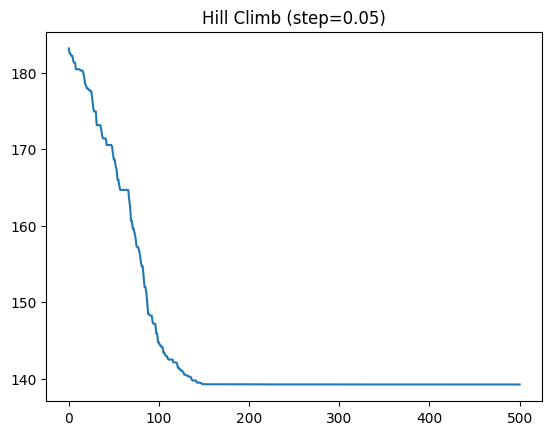

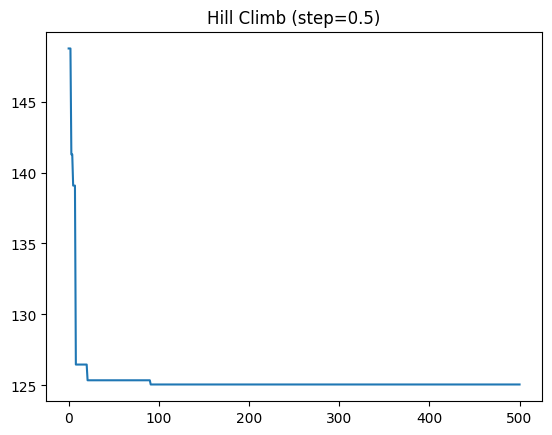

In [5]:
sol1, val1, hist1 = hill_climb(step_size=0.05)
sol2, val2, hist2 = hill_climb(step_size=0.5)

plt.figure()
plt.plot(hist1)
plt.title("Hill Climb (step=0.05)")
plt.show()

plt.figure()
plt.plot(hist2)
plt.title("Hill Climb (step=0.5)")
plt.show()

Observation

Small step → slow but stable

Large step → faster but unstable

Gets stuck in local minima (because function is multimodal)

✅ 3️⃣ Particle Swarm Optimization (PSO)
Idea:

Multiple particles

Personal best + Global best

Exploration + Exploitation

In [7]:
def pso(n_particles=30, w=0.7, c1=1.5, c2=1.5, max_iter=300):

    particles = np.random.uniform(-10, 10, (n_particles, 3))
    velocities = np.zeros((n_particles, 3))

    pbest = particles.copy()
    pbest_val = np.array([objective(p) for p in particles])

    gbest = pbest[np.argmin(pbest_val)]
    gbest_val = min(pbest_val)

    history = []

    for _ in range(max_iter):
        for i in range(n_particles):
            r1, r2 = np.random.rand(), np.random.rand()

            velocities[i] = (w * velocities[i] +
                             c1 * r1 * (pbest[i] - particles[i]) +
                             c2 * r2 * (gbest - particles[i]))

            particles[i] += velocities[i]
            value = objective(particles[i])

            if value < pbest_val[i]:
                pbest[i] = particles[i]
                pbest_val[i] = value

        gbest = pbest[np.argmin(pbest_val)]
        gbest_val = min(pbest_val)

        history.append(gbest_val)

    return gbest, gbest_val, history

Hyperparameter Study (inertia weight)

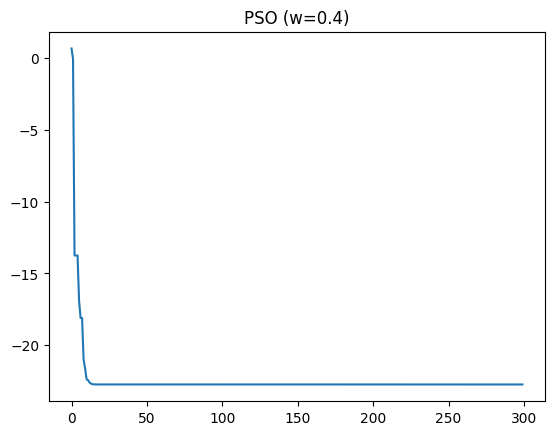

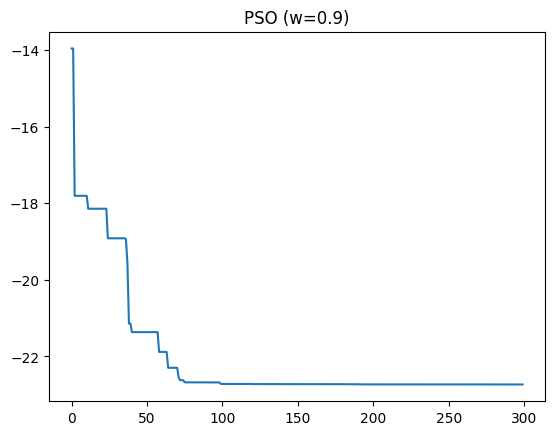

In [8]:
sol3, val3, hist3 = pso(w=0.4)
sol4, val4, hist4 = pso(w=0.9)

plt.figure()
plt.plot(hist3)
plt.title("PSO (w=0.4)")
plt.show()

plt.figure()
plt.plot(hist4)
plt.title("PSO (w=0.9)")
plt.show()

Observation

Low w → fast convergence

High w → more exploration

Usually finds better minimum than Hill Climb

⚙️ How BBO Works (Steps)

1️⃣ Initialize population \
2️⃣ Evaluate objective (HSI) \
3️⃣ Rank habitats \
4️⃣ Calculate immigration (λ) and emigration (μ) rates \
5️⃣ Migration (feature sharing) \
6️⃣ Mutation \
7️⃣ Repeat

In [9]:
def bbo(pop_size=30, max_iter=300, mutation_rate=0.1):

    population = np.random.uniform(-10, 10, (pop_size, 3))
    history = []

    for _ in range(max_iter):

        fitness = np.array([objective(p) for p in population])
        sorted_idx = np.argsort(fitness)
        population = population[sorted_idx]
        fitness = fitness[sorted_idx]

        best = population[0].copy()
        best_val = fitness[0]

        # Migration
        for i in range(1, pop_size):
            if np.random.rand() < (i / pop_size):
                donor = np.random.randint(0, pop_size//2)
                dim = np.random.randint(0, 3)
                population[i, dim] = population[donor, dim]

        # Mutation
        for i in range(pop_size):
            if np.random.rand() < mutation_rate:
                dim = np.random.randint(0, 3)
                population[i, dim] = np.random.uniform(-10, 10)

        history.append(best_val)

    return best, best_val, history

In [10]:
sol_bbo, val_bbo, hist_bbo = bbo()

print("Best Solution (BBO):", sol_bbo)
print("Best Value (BBO):", val_bbo)

Best Solution (BBO): [ 0.74925492 -0.81788007  1.00679995]
Best Value (BBO): -22.61196305985345


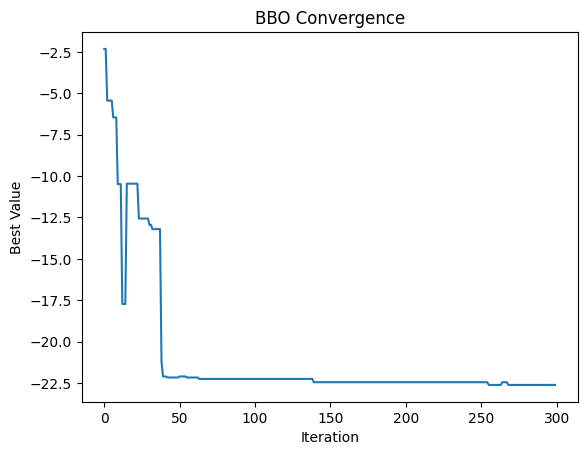

In [11]:
plt.figure()
plt.plot(hist_bbo)
plt.title("BBO Convergence")
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.show()

✅ Hyperparameter Study – Mutation Rate

We change mutation_rate to study its effect.

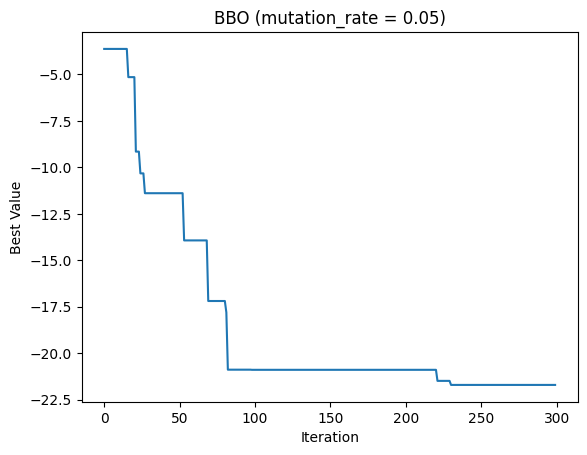

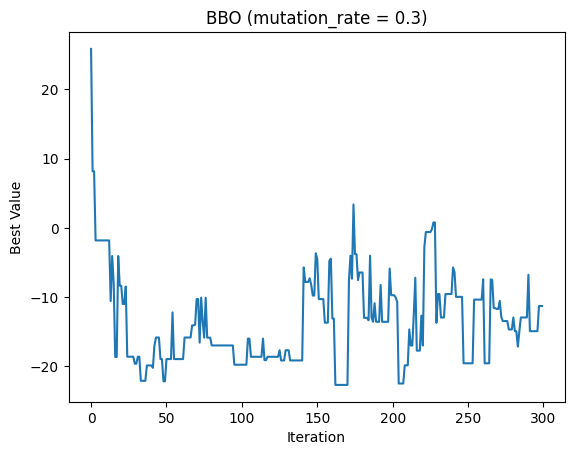

In [12]:
sol1, val1, hist1 = bbo(mutation_rate=0.05)
sol2, val2, hist2 = bbo(mutation_rate=0.3)

plt.figure()
plt.plot(hist1)
plt.title("BBO (mutation_rate = 0.05)")
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.show()

plt.figure()
plt.plot(hist2)
plt.title("BBO (mutation_rate = 0.3)")
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.show()

✅ Hyperparameter Study – Population Size

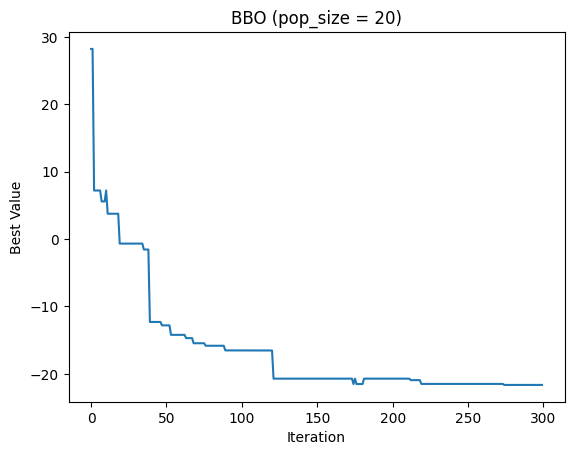

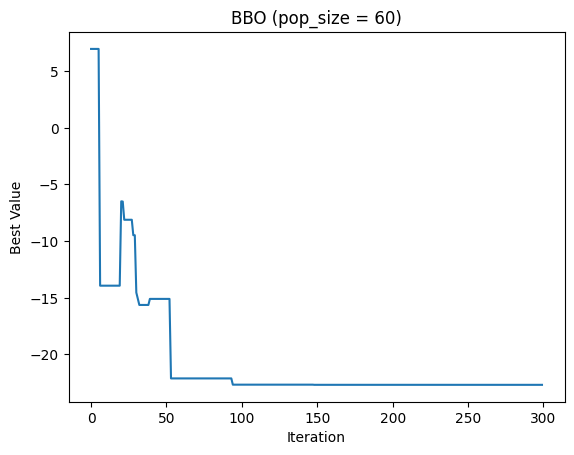

In [13]:
sol3, val3, hist3 = bbo(pop_size=20)
sol4, val4, hist4 = bbo(pop_size=60)

plt.figure()
plt.plot(hist3)
plt.title("BBO (pop_size = 20)")
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.show()

plt.figure()
plt.plot(hist4)
plt.title("BBO (pop_size = 60)")
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.show()

🎯 Observations :

• Low mutation → slow exploration \
• High mutation → more randomness \
• Small population → fast but unstable \
• Large population → better search but slower